---
numbering: false
---

# 6.4. The Complete Solution and the Projection Matrix

In [Chapter 6.3](./03-projecting-onto-column-space.ipynb), we explored the idea of projecting a vector onto the column space of a matrix. If $\color{#3d81f6} X$ has linearly independent columns, then the vector in $\text{colsp}({\color{#3d81f6} X})$ that is closest to $\color{orange} \vec y$ is the vector ${\color{#3d81f6} X} \vec w^*$, where $\vec w^*$ is the unique solution to the normal equation,

$${\color{#3d81f6} X^T} {\color{#3d81f6} X} \vec w^* = {\color{#3d81f6} X^T} {\color{orange} \vec y}$$

When $\color{#3d81f6} X$ has linearly independent columns, then ${\color{#3d81f6} X^T} {\color{#3d81f6} X}$ is invertible, so we can solve for $\vec w^*$ uniquely.

$$\vec w^* = ({\color{#3d81f6} X^T} {\color{#3d81f6} X})^{-1} {\color{#3d81f6} X^T} {\color{orange} \vec y}$$

---

## What if $\color{#3d81f6} X$'s Columns are Linearly Dependent?

In the case where $\color{#3d81f6} X$'s columns are linearly dependent, we can't invert $\color{#3d81f6} X^T \color{#3d81f6} X$ to solve for $\vec w^*$. This means that

$${\color{#3d81f6} X^T} {\color{#3d81f6} X} \vec w = {\color{#3d81f6} X^T} {\color{orange} \vec y}$$

has infinitely many solutions. Let's give more thought to what these solutions actually are.

First, note that all of these solutions for $\vec w^*$ **correspond to the same projection,** $\vec p = X \vec w^*$. The "best approximation" of $\color{orange} \vec y$ in $\text{colsp}({\color{#3d81f6}X})$ is always just one vector; if there are infinitely many $\vec w^*$'s, that just means there are infinitely many ways of describing that one best approximation. Remember, if vectors are linearly independent, then any of their linear combinations can only be expressed in one way; if they are linearly dependent, then their linear combinations can be expressed in infinitely many ways.

In other words, if $\color{#3d81f6} X$ has linearly dependent columns, then there are infinitely many $\vec w^*$'s that satisfy the normal equation, but they all correspond to the same projection $\vec p = {\color{#3d81f6} X} \vec w^*$ in the figure below.

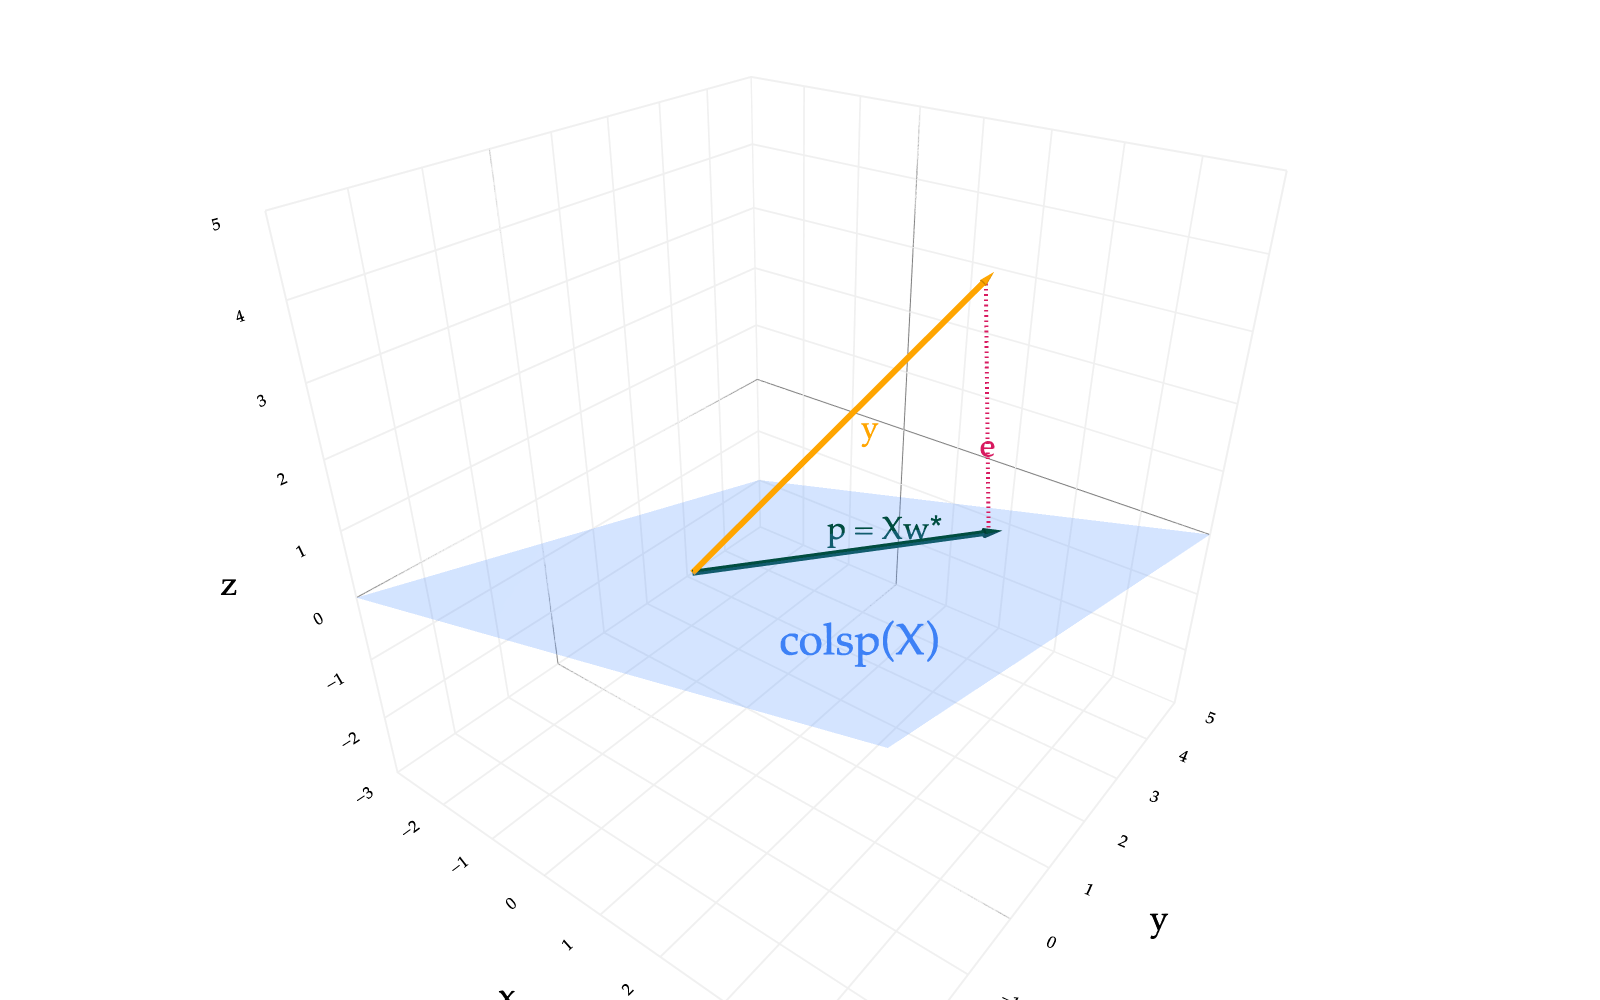

In [3]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

y = np.array([1, 3, 2]) * 1.5
v1 = (1, 0, 0.25)
v2 = np.array([2, 2, 0]) * 0.5

def create_base_fig(show_spanners=True):
    # Define the vectors
    v3 = (-3.5 * v1[0] + 4 * v2[0], -3.5 * v1[1] + 4 * v2[1], -3.5 * v1[2] + 4 * v2[2])  # v3 is v1 + v2, which is on the plane spanned by v1 and v2

    # Plot the vectors using plot_vectors function
    vectors = [
        (tuple(y), "orange", "y"),
        (v1, "#3d81f6", "x⁽¹⁾"), 
        (tuple(-v2), "#3d81f6", "x⁽²⁾"),
        (v3, "#3d81f6", "x⁽³⁾")
    ]
    
    if not show_spanners:
        vectors = [vectors[0]]

    fig = plot_vectors(vectors, show_axis_labels=True, vdeltaz=5, vdeltax=1)

    # Make the plane look more rectangular by using a smaller, symmetric range for s and t
    plane_extent = 20  # controls the "size" of the rectangle
    num_points = 3   # fewer points for a cleaner rectangle

    s_range = np.linspace(-plane_extent, plane_extent, num_points)
    t_range = np.linspace(-plane_extent, plane_extent, num_points)
    s_grid, t_grid = np.meshgrid(s_range, t_range)

    plane_x = s_grid * v1[0] + t_grid * v2[0]
    plane_y = s_grid * v1[1] + t_grid * v2[1]
    plane_z = s_grid * v1[2] + t_grid * v2[2]

    fig.add_trace(go.Surface(
        x=plane_x,
        y=plane_y,
        z=plane_z,
        opacity=0.8,
        colorscale=[[0, 'rgba(61,129,246,0.3)'], [1, 'rgba(61,129,246,0.3)']],
        showscale=False,
    ))

    # Annotate the plane with "colsp(X)"
    # Move the annotation "down" the plane by choosing negative s and t values
    label_s = 0.3
    label_t = 0.9
    label_x = label_s * v1[0] + label_t * v2[0]
    label_y_coord = label_s * v1[1] + label_t * v2[1] - 2
    label_z = label_s * v1[2] + label_t * v2[2]

    fig.add_trace(go.Scatter3d(
        x=[4],
        y=[-2],
        z=[2],  # small offset above the plane for visibility
        mode="text",
        text=[r"colsp(X)"],
        textposition="middle center",
        textfont=dict(size=22, color="#3d81f6"),
        showlegend=False
    ))

    # Set equal ranges for all axes to make grid boxes square
    axis_range = [-3, 5]  # Same range for all axes
    
    fig.update_layout(
        scene_camera=dict(
            eye=dict(x=1, y=-1.3, z=1)
        ),
        scene=dict(
            xaxis=dict(
                range=axis_range,
                dtick=1,
            ),
            yaxis=dict(
                range=axis_range,
                dtick=1,
            ),
            zaxis=dict(
                range=axis_range,
                dtick=1,
            ),
            aspectmode="cube",
            aspectratio=dict(x=1, y=1, z=1),  # Explicitly set 1:1:1 ratio
        ),
    )
    return fig

def plot_vectors_with_errors(vectors_list, base_fig=None, notation="0"):
    """
    Takes a list of vectors and draws each one in #004d40 with a dotted error line in #d81a60.
    
    Parameters:
    -----------
    vectors_list : list of array-like
        List of vectors to plot. Each vector should be a 3D point/vector.
    base_fig : plotly.graph_objects.Figure, optional
        Base figure to build upon. If None, creates a new base figure using create_base_fig().
    
    Returns:
    --------
    fig : plotly.graph_objects.Figure
        The figure with vectors and error lines added.
    """
    fig = create_base_fig(show_spanners=False)
    
    # Get y vector from create_base_fig (defined the same way)
    y = np.array([1, 3, 2]) * 1.5
    
    for i, vec in enumerate(vectors_list):
        vec = np.array(vec)
        
        # Draw the vector in #004d40
        fig.add_trace(go.Scatter3d(
            x=[0, vec[0]],
            y=[0, vec[1]],
            z=[0, vec[2]],
            mode='lines',
            line=dict(color='#004d40', width=6),
            showlegend=False
        ))
        
        # Add arrowhead for the vector
        fig.add_trace(go.Cone(
            x=[vec[0]],
            y=[vec[1]],
            z=[vec[2]],
            u=[vec[0]],
            v=[vec[1]],
            w=[vec[2]],
            colorscale=[[0, '#004d40'], [1, '#004d40']],
            showscale=False,
            sizemode="absolute",
            sizeref=0.3,
            showlegend=False
        ))
        
        # Draw the error line (dotted) from vec to y in #d81a60
        fig.add_trace(go.Scatter3d(
            x=[vec[0], y[0]],
            y=[vec[1], y[1]],
            z=[vec[2], y[2]],
            mode='lines',
            line=dict(color='#d81a60', width=4, dash='dash'),
            showlegend=False
        ))

        # Annotate the vectors and error lines
        if i == 0:
            # Annotate the vector as Xw₀
            fig.add_trace(go.Scatter3d(
                x=[1], y=[3], z=[-0.5],
                mode='text',
                text=["p\u2080 = Xw\u2080"] if notation == "0" else ["p = Xw*"],  # \u2080 is Unicode subscript zero
                textposition="middle center",
                textfont=dict(color='#004d40', size=16),
                showlegend=False
            ))
            # Annotate the error as e₀
            mid_error = (vec + y) / 2
            fig.add_trace(go.Scatter3d(
                x=[mid_error[0]],
                y=[mid_error[1]],
                z=[mid_error[2]],
                mode='text',
                text=["e\u2080"] if notation == "0" else ["e"],
                textposition="bottom center",
                textfont=dict(color='#d81a60', size=16),
                showlegend=False
            ))
        else:
            # Annotate the vector as Xw'
            fig.add_trace(go.Scatter3d(
                x=[2], y=[-1], z=[1],
                mode='text',
                text=["p' = Xw'"],
                textposition="middle center",
                textfont=dict(color='#004d40', size=16),
                showlegend=False
            ))
            # Annotate the error as e'
            mid_error = (vec + y) / 2
            fig.add_trace(go.Scatter3d(
                x=[mid_error[0]],
                y=[mid_error[1]],
                z=[mid_error[2]],
                mode='text',
                text=["e'"],
                textposition="bottom center",
                textfont=dict(color='#d81a60', size=16),
                showlegend=False
            ))
    
    return fig

fig = create_base_fig()

# y = np.array([1, 3, 2]) * 1.5
# v1 = (1, 0, 0.25)
# v2 = np.array([2, 2, 0]) * 0.5

X = np.vstack([v1, v2]).T
w = np.linalg.inv(X.T @ X) @ X.T @ y
# w = [-1.333, 3.6667]
p = X @ w
test_vectors = [p]

# Plot vectors with errors and draw a right angle between p and e
fig = plot_vectors_with_errors(test_vectors, fig, notation='*')
fig.show(renderer='png', scale=2)

Let me drive this point home further. Let's suppose both $\vec w_1$ and $\vec w_2$ satisfy

$${\color{#3d81f6} X^T} {\color{#3d81f6} X} \vec w = {\color{#3d81f6} X^T} {\color{orange} \vec y}$$

Then,

$$X^TX \vec w_1 - X^TX \vec w_2 = \vec y - \vec y = \vec 0$$

which means that

$$(X^TX)(\vec w_1 - \vec w_2) = \vec 0$$

i.e. the difference between the two vectors, $\vec w_1 - \vec w_2$, is in $\text{nullsp}(X^TX)$. But, back in [Chapter 5.3](../05_matrices/03-rank-and-column-space.ipynb), we proved that $X^TX$ and $X$ have the same null space, meaning any vector that gets sent to $\vec 0$ by $X$ also gets sent to $\vec 0$ by $X^TX$, and vice versa.

So,

$$X(\vec w_1 - \vec w_2) = \vec 0$$

too, but that just means

$$X \vec w_1 = X \vec w_2$$

meaning that even though $\vec w_1$ and $\vec w_2$ are different-looking coefficient vectors, they both still correspond to the **same** linear combination of $X$'s columns!

Let's see how we can apply this to an example. Let ${\color{#3d81f6} X = \begin{bmatrix} 3 & 1 & 0 \\ 6 & 2 & 1 \\ 3 & 1 & 0 \end{bmatrix}}$ and ${\color{orange} \vec y = \begin{bmatrix} 2 \\ 1 \\ 3 \end{bmatrix}}$. This is an example of a matrix with linearly dependent columns, so there's no unique $\vec w^*$ that satisfies the normal equations.


### Finding One Solution

One way to find a possible vector $\vec w^*$ is to solve the normal equations. $\color{#3d81f6} X^T \color{#3d81f6} X$ is not invertible, so we can't solve for $\vec w^*$ uniquely, but we can still try and find a solution.

Here's one approach: let's just toss out the linearly dependent columns of $\color{#3d81f6} X$ and solve for $\vec w^*$ using the remaining columns. Then, $\vec w^*$ for the full $\color{#3d81f6} X$ can use the same coefficients for the linearly independent columns, but 0s for the dependent ones. **Removing the linearly dependent columns does not change $\text{colsp}({\color{#3d81f6} X})$ (i.e. the set of all linear combinations of $\color{#3d81f6} X$'s columns), so the projection is the same.**

The easy solution is to keep columns 2 and 3, since their numbers are smallest. So, for now, let's say

$$X' = \begin{bmatrix} 1 & 0 \\ 2 & 1 \\ 1 & 0 \end{bmatrix}, \quad \color{orange} \vec y = \begin{bmatrix} 2 \\ 1 \\ 3 \end{bmatrix}$$

Here, $\vec w' = (X'^T X')^{-1} X'^T {\color{orange} \vec y} = \begin{bmatrix} 5/2 \\ -4 \end{bmatrix}$. I won't bore you with the calculations; you can verify them yourself.

Now, **one** possible $\vec w^*$ for the full $\color{#3d81f6} X$ is $\begin{bmatrix} 0 \\ 5/2 \\ -4\end{bmatrix}$, which keeps the same coefficients on columns 2 and 3 as in $\vec w'$, but 0 for the column we didn't use.

### Finding All Solutions

As I mentioned above, if there are infinitely many solutions to the normal equation, then the **difference** between any two solutions is in $\text{nullsp}({\color{#3d81f6} X^TX})$, which is also $\text{nullsp}({\color{#3d81f6} X})$. Put another way, if $\vec w_s$ satisfies the normal equations, then so does $\vec w_s + \vec n$ for any $\vec n \in \text{nullsp}({\color{#3d81f6} X^TX})$.

\begin{align*}
{\color{#3d81f6} X^T X} \vec w_s &= {\color{#3d81f6} X^T} \color{orange} \vec y \\
{\color{#3d81f6} X^T X} (\vec w_s + \vec n) &= 
{\color{#3d81f6} X^T X} \vec w_s + \underbrace{{\color{#3d81f6} X^T X} \vec n}_{\vec 0, \text{ by definition of null space}} &= {\color{#3d81f6} X^T} {\color{orange} \vec y} + \vec 0 \\
\end{align*}

So, once we have one $\vec w^*$, to get the rest, just add any vector in $\text{nullsp}({\color{#3d81f6} X^TX})$ or $\text{nullsp}({\color{#3d81f6} X})$ (since those are the same subspaces).

What is $\text{nullsp}({\color{#3d81f6} X})$? It's the set of vectors $\vec v$ such that ${\color{#3d81f6} X} \vec v = \vec 0$.

In our particular example,

$${\color{#3d81f6} X = \begin{bmatrix} 3 & 1 & 0 \\ 6 & 2 & 1 \\ 3 & 1 & 0 \end{bmatrix}}$$

we see that $\text{rank}({\color{#3d81f6} X}) = 2$, so $\text{nullsp}({\color{#3d81f6} X})$ has a dimension of $3 - 2 = 1$ (by the rank-nullity theorem), so it's going to be the span of a single vector. All we need to do now is find **one** vector in $\text{nullsp}({\color{#3d81f6} X})$, and we will know that the null space is the set of scalar multiples of that vector.

Since column 1 is three times column 2, the vector $\vec v = \begin{bmatrix} 1 \\ -3 \\ 0 \end{bmatrix}$ must be in $\text{nullsp}({\color{#3d81f6} X})$.

$${\color{#3d81f6} X} \begin{bmatrix} 1 \\ -3 \\ 0 \end{bmatrix} = {\color{#3d81f6}\begin{bmatrix} 3 & 1 & 0 \\ 6 & 2 & 1 \\ 3 & 1 & 0 \end{bmatrix}}\begin{bmatrix} 1 \\ -3 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

So, since $\text{nullsp}({\color{#3d81f6} X}) = \text{nullsp}({\color{#3d81f6} X^TX}) = \text{span}\left(\left\{\begin{bmatrix} 1 \\ -3 \\ 0 \end{bmatrix}\right\}\right)$, we know that the set of all possible $\vec w^*$'s is

$$\underbrace{\begin{bmatrix} 0 \\ 5/2 \\ -4 \end{bmatrix} + t\begin{bmatrix} 1 \\ -3 \\ 0 \end{bmatrix}, t \in \mathbb{R}}_\text{there are infinitely many solutions to the normal equations, but they're all of this form}$$

This is **not** a subspace, since it doesn't contain the zero vector.

:::{attention} Finding all solutions when there are infinitely many
If $\color{#3d81f6} X$ has linearly dependent columns, and $\vec w'$ satisfies the normal equation, then $\vec w' + \vec n$ is also a solution to the normal equation for any $\vec n \in \text{nullsp}({\color{#3d81f6} X^TX})$, or equivalently, $\vec n \in \text{nullsp}({\color{#3d81f6} X})$.
:::

<br>

There's another way to arrive at this set of possible $\vec w^*$'s: we can solve the normal equations directly. I wouldn't recommend this second approach since it's much longer, but I'll add it here for completeness.

$$
\begin{align*}
{\color{#3d81f6}X^TX}&={\color{#3d81f6}\begin{bmatrix} 3 & 6 & 3 \\ 1 & 2 & 1 \\ 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} 3 & 1 & 0 \\ 6 & 2 & 1 \\ 3 & 1 & 0 \end{bmatrix}}={\color{#3d81f6}\begin{bmatrix}54 & 18 & 6 \\ 18 & 6 & 2 \\ 6 & 2 & 1 \end{bmatrix}}
\\
\\ {\color{#3d81f6}X^T}{\color{orange}\vec y}&={\color{#3d81f6}\begin{bmatrix} 3 & 6 & 3 \\ 1 & 2 & 1 \\ 0 & 1 & 0 \end{bmatrix}}{\color{orange}\begin{bmatrix} 2 \\ 1 \\ 3 \end{bmatrix}}=\begin{bmatrix} 21 \\ 7 \\ 1 \end{bmatrix}
\end{align*}
$$

Then, the normal equations ${\color{#3d81f6}X^TX}\vec w^*={\color{#3d81f6}X^T}\color{orange}\vec y$ give us

$$
\begin{align*}
54w^*_1 + 18w^*_2 + 6w^*_3 &= 21
\\18w^*_1 + 6w^*_2 + 2w^*_3&=7
\\6w^*_1 + 2w^*_2 + w^*_3 &= 1
\end{align*}
$$
The first and second equations are just scalar multiples of each other, so we can disregard one of them, and solve for a form where we can use one unknown as a parameter for the other two. To illustrate, let's pick $w_1^* = t$.

\begin{align*}
18t + 6w^*_2 + 2w^*_3&=7 \tag{2}
\\6t + 2w^*_2 + w^*_3 &= 1 \tag{3}
\end{align*}

$(2) - 3 \cdot (3)$ gives us $w_3^* = -4$. Plugging this into both equations gives us

\begin{align*}
18t + 6w_2^* - 8 &= 7 \implies 18t + 6w_2^* &= 15
\\6t + 2w_2^* - 4 &= 1 \implies 6t + 2w_2^* &= 5
\end{align*}

These are now both the same equation; the first one is just $3$ times the second. So, we can solve for $w_2^*$ in terms of $t$:

$$w_2^* = \frac{5-6t}{2}$$

which gives us the complete solution

$$\vec w^* = \begin{bmatrix} t \\ \frac{5-6t}{2} \\ -4 \end{bmatrix}, t \in \mathbb{R}$$

**This is the exact same line as using the null space approach!** Plug in $t = 0$ to get $\begin{bmatrix} 0 \\ 5/2 \\ -4 \end{bmatrix}$, for example. The set of all possible $\vec w^*$'s is **not a subspace**, since it doesn't contain the zero vector.

---

## The Projection Matrix

So far, we've established that the vector in $\text{colsp}({\color{#3d81f6} X})$ that is closest to $\color{orange} \vec y$ is the vector ${\color{#3d81f6} X} \vec w^*$, where $\vec w^*$ is the solution to the normal equations,

$${\color{#3d81f6} X^T X} \vec w^* = {\color{#3d81f6} X^T} \color{orange} \vec y$$

If $X^TX$ is invertible, then $\vec w^*$ is the unique vector

$$\vec w^* = ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T \color{orange} \vec y$$

meaning that the vector in $\text{colsp}({\color{#3d81f6} X})$ that is closest to $\color{orange} \vec y$ is

$$\vec p = {\color{#3d81f6} X} \vec w^* = {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T \color{orange} \vec y$$

You'll notice that the above expression also looks like a linear transformation applied to $\color{orange} \vec y$, where $\color{orange} \vec y$ is being multiplied by the matrix

$$P = {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T$$

The matrix $P$ is called the **projection matrix**. In other classes, it is called the "hat matrix", because they might use $\hat{\mathbf{w}}$ instead of $\vec w^*$ and $\hat{\mathbf{y}}$ instead of $\vec p$, and in that notation, $\hat{\mathbf{y}} = P \mathbf{y}$, so $P$ puts a "hat" on $\mathbf{y}$. (I don't use hat notation in this class because drawing a hat on top of a vector is awkward. Doesn't $\hat{\vec w}$ look strange?)

So,

$$\vec p = {\color{#3d81f6} X} \vec w^* = P \color{orange} \vec y$$

shows us that there are two ways to interpret the act of projecting $\color{orange} \vec y$ onto $\text{colsp}({\color{#3d81f6} X})$:
1. The resulting vector is some optimal linear combination of ${\color{#3d81f6} X}$'s columns.
1. The resulting vector is the result of applying the linear transformation $P$ to $\color{orange} \vec y$.

Let's work out an example. Suppose 

$${\color{#3d81f6} X = \begin{bmatrix} {\color{#3d81f6} 3} & {\color{#3d81f6} 0} \\ {\color{#3d81f6} 0} & {\color{#3d81f6} 154} \\ {\color{#3d81f6} 6} & {\color{#3d81f6} 0} \end{bmatrix}}, \quad {\color{orange} \vec y = \begin{bmatrix} {\color{orange} 1} \\ {\color{orange} 2} \\ {\color{orange} 3} \end{bmatrix}}$$

$\color{#3d81f6} X$'s columns are linearly independent, so $\color{#3d81f6} X^T X$ is invertible, and $$P = {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T$$ is well-defined.

In [6]:
X = np.array([[3, 0], 
              [0, 154], 
              [6, 0]])

P = X @ np.linalg.inv(X.T @ X) @ X.T
P

array([[0.2, 0. , 0.4],
       [0. , 1. , 0. ],
       [0.4, 0. , 0.8]])

In [7]:
P @ np.array([1, 2, 3])

array([1.4, 2. , 2.8])

$P = \begin{bmatrix} 0.2 & 0 & 0.4 \\ 0 & 1 & 0 \\ 0.4 & 0 & 0.8 \end{bmatrix}$ contains the information we need to project $\color{orange} \vec y$ onto $\text{colsp}({\color{#3d81f6} X})$. Each row of $P$ tells us the right mixture of $\color{orange} \vec y$'s components we need to construct the projection.

Notice that $P$'s second row is $\begin{bmatrix} 0 & 1 & 0 \end{bmatrix}^T$. This came from the fact that $\color{#3d81f6} X$'s first column had a second component of 0 while its second column had a non-zero second component but zeros in the other two components, meaning that we can scale $\color{#3d81f6} X$'s second column to exactly match $\color{orange} \vec y$'s second component. Change the $154$ in $\color{#3d81f6} X$ to any other non-zero value and $P$ won't change!

Additionally, if we consider some $\color{orange} \vec y$ that is already in $\text{colsp}({\color{#3d81f6} X})$, then multiplying it by $P$ doesn't change it! For example, if we set $\color{orange} \vec y = \begin{bmatrix} 3 \\ 154 \\ 6 \end{bmatrix}$ (the sum of $\color{#3d81f6} X$'s columns), then $P {\color{orange} \vec y} = {\color{orange} \vec y}$.

In [9]:
P @ np.array([3, 154, 6])

array([  3., 154.,   6.])

Let's work through some examples that develop our intuition for $P$.


### Example: Is $P$ invertible?

Suppose $P = {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T$ exists, meaning $\color{#3d81f6} X^T X$ is invertible. Is $P$ invertible? If so, what is its inverse?

:::{seealso} Solution
:class: dropdown

Before we do any calculations, intuitively the answer should be **no**. Once we've projected onto $\text{colsp}({\color{#3d81f6} X})$, we've lost information, since we went from an arbitrary vector in $\mathbb{R}^n$ to a vector in a smaller subspace, so it shouldn't be possible to reverse the projection. Put another way, two different vectors in $\mathbb{R}^n$ might have the same "shadow" onto $\text{colsp}({\color{#3d81f6} X})$.

Even in the most recent example, $P = \begin{bmatrix} 0.2 & 0 & 0.4 \\ 0 & 1 & 0 \\ 0.4 & 0 & 0.8 \end{bmatrix}$ is not invertible, since column 3 is a multiple of column 1.

Let's think about this a bit more from the perspective of ranks. It turns out that $\text{rank}(P) = \text{rank}({\color{#3d81f6}X})$; I've provided a proof of this at the bottom of the solutions box, but you might want to attempt it on your own for practice.

Remember that $\color{#3d81f6} X$ is an $n \times d$ matrix, meaning $\text{rank}({\color{#3d81f6}X}) \leq \min(n, d)$. $\color{#3d81f6} X$ doesn't need to have a rank of $n$ for $\color{#3d81f6} X^TX$ to be invertible; it just needs to have a rank of $d$. 

Since $P$ is an $n \times n$ matrix, in general it won't be the case that $\text{rank}(P) = n$. To illustrate, in the example above where $P = \begin{bmatrix} 0.2 & 0 & 0.4 \\ 0 & 1 & 0 \\ 0.4 & 0 & 0.8 \end{bmatrix}$, $X$ was a $3 \times 2$ matrix with rank 2.

The only case in which $\text{rank}(P) = n$ is when $\text{rank}({\color{#3d81f6}X}) = n$, which also only happens when $\color{#3d81f6} X$ is an $n \times n$ square matrix that is also invertible. In such a case, $\text{colsp}({\color{#3d81f6}X}) = \mathbb{R}^n$, and so we probably wouldn't set out to project onto $\text{colsp}({\color{#3d81f6} X})$ in the first place, since any vector in $\mathbb{R}^n$ is already a linear combination of ${\color{#3d81f6} X}$'s columns.

<br>

**Extra**: Proof that $\text{rank}(P) = \text{rank}({\color{#3d81f6} X})$

We can show that this is the case by showing that $P$ and $\color{#3d81f6} X$ both have the same column spaces. **This proof also helps explain why the normal equation, ${\color{#3d81f6} X^TX} \vec w = {\color{#3d81f6}X^T} \color{orange} \vec y$, always has at least one solution for $\vec w$, even when $\color{#3d81f6} X^TX$ isn't invertible.**

1. **Show $\text{colsp}(P) \subseteq \text{colsp}({\color{#3d81f6} X})$**, i.e. show that any vector in the column space of $P$ is also in the column space of $\color{#3d81f6} X$.

    If $\vec v \in \text{colsp}(P)$, then $\vec v$ can be written as a linear combination of $P$'s columns. Say $\vec v = P \vec u$ for some $\vec u \in \mathbb{R}^n$. Then, 

    $$\vec v = P \vec u =  {\color{#3d81f6} X} \underbrace{\left( ({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} \vec u  \right)}_{\text{some vector}}$$
    Here, we see that if $\vec v = P \vec u$, then $\vec v$ is also in ${\color{#3d81f6} X}$'s column space. So,
    $$\vec v \text{ is a lin. comb. of $P$'s columns} \implies \vec v \text{ is a lin. comb. of ${\color{#3d81f6} X}$'s columns}$$

2. **Show $\text{colsp}({\color{#3d81f6} X}) \subseteq \text{colsp}(P)$**, i.e. show that any vector in the column space of $\color{#3d81f6} X$ is also in the column space of $P$.

    This direction is a bit more involved. Let's start by considering some vector $\vec v \in \text{colsp}({\color{#3d81f6} X})$, meaning $$\vec v = {\color{#3d81f6} X} \vec u$$ for some $\vec u \in \mathbb{R}^d$. What happens if we multiply both sides by $P$?

    $$\begin{align*} \vec v &= {\color{#3d81f6} X} \vec u \\ P \vec v &= P {\color{#3d81f6} X} \vec u \\ P \vec v &= \underbrace{{\color{#3d81f6} X}({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T}}_P {\color{#3d81f6}X} \vec u \\ P \vec v &= {\color{#3d81f6} X}\underbrace{({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} {\color{#3d81f6}X}}_I \vec u \\ P \vec v &= \underbrace{{\color{#3d81f6} X} \vec u = \vec v}_{\text{original definition of $\vec v$}} \end{align*}$$

    If $\vec v \in \text{colsp}({\color{#3d81f6} X})$, then $\vec v$ can be written as a linear combination of ${\color{#3d81f6} X}$'s columns. Say $\vec v = {\color{#3d81f6} X} \vec w$ for some $\vec w \in \mathbb{R}^d$. Then, 

    $$\vec v = {\color{#3d81f6} X} \vec w = P \vec w$$

    So, if $\vec v = {\color{#3d81f6} X} \vec u$, then $\vec v = P \vec v$, meaning that $\vec v$ is also in $P$'s column space if it's in ${\color{#3d81f6} X}$'s column space. Intuitively, $\vec v = P \vec v$ means that if $\vec v$ is already in the span of $\color{#3d81f6} X$'s columns, then projecting it onto $\text{colsp}({\color{#3d81f6} X})$ doesn't change it.

Now that we've shown that $\text{colsp}(P) \subseteq \text{colsp}({\color{#3d81f6} X})$ and $\text{colsp}({\color{#3d81f6} X}) \subseteq \text{colsp}(P)$, we can conclude that $\text{colsp}(P) = \text{colsp}({\color{#3d81f6} X})$. If two sets are subsets of each other, then they must be equal.
:::

### Example: Is $P$ orthogonal?

Is $P$ orthogonal?

:::{seealso} Solution
:class: dropdown

**No**. Orthogonal matrices $Q$ have the property that $Q^TQ = QQ^T = I$, meaning that $$Q^T = Q^{-1}$$

But, as we saw, $P$ is not invertible in general, so it can't satisfy this property. This tells us that $P$ **does not perform a rotation**; projections are not rotations. Rotations can be undone but projections can't.
:::

### Example: Is $P$ symmetric?

Is $P$ symmetric?

:::{seealso} Solution
:class: dropdown

**Yes**. Symmetric matrices $A$ have the property that $A^T = A$. We can show that $P$ satisfies this property; to do so, we'll need to use the fact that $(AB)^T = B^T A^T$.

$$\begin{align*} P^T &= \left( {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} \right)^T \\ &= \left( {\color{#3d81f6} X^T} \right)^T \left( ({\color{#3d81f6} X^T X})^{-1} \right)^T {\color{#3d81f6} X^T} \\ &= {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T \\ &= P \end{align*}$$

Going from the second to the third line, we used the fact that $\color{#3d81f6} X^TX$ is symmetric, and so is its inverse. Remember that $\color{#3d81f6} X^T X$ is a square matrix consisting of the dot products of the columns of $\color{#3d81f6} X$ with themselves.
:::

### Example: Is $P$ idempotent?

Recall, an idemponent matrix $A$ satisfies $A^2 = A$. Is $P$ idempotent?

:::{seealso} Solution
:class: dropdown

**Yes**.

$$\begin{align*} P^2 &= P \cdot P \\ &= \left({\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} \right) {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T \\ &= {\color{#3d81f6} X} \underbrace{\left( ({\color{#3d81f6} X^T X})^{-1} {\color{#3d81f6} X^T} {\color{#3d81f6} X} \right)}_{I} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T \\ &= {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T \\ &= P \end{align*}$$

Intuitively, this means that $P^2 {\color{orange} \vec y}$ is the same as $P {\color{orange} \vec y}$, meaning that once we've projected $\vec y$ onto $\text{colsp}({\color{#3d81f6} X})$, projecting its projection $\vec p$ again onto $\text{colsp}({\color{#3d81f6} X})$ gives us back the same $\vec p$, since $\vec p$ is already in $\text{colsp}({\color{#3d81f6} X})$.

:::

### Example: What is $PX$, and why?

What is $PX$? What does the result mean?

:::{seealso} Solution
:class: dropdown

$$\begin{align*} P{\color{#3d81f6} X} &= {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T {\color{#3d81f6} X} \\ &= {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T {\color{#3d81f6} X} \\ &= {\color{#3d81f6} X} I \\ &= {\color{#3d81f6} X} \end{align*}$$

Interpret $P {\color{#3d81f6} X}$ as a matrix made up of $P \color{#3d81f6} \vec x^{(1)}$, $P \color{#3d81f6} \vec x^{(2)}$, ..., $P \color{#3d81f6} \vec x^{(d)}$ as its columns. $P \color{#3d81f6} \vec x^{(i)}$ is the projection of $\color{#3d81f6} \vec x^{(i)}$ onto $\text{colsp}({\color{#3d81f6} X})$, but since $\color{#3d81f6} \vec x^{(i)}$ is already in $\text{colsp}({\color{#3d81f6} X})$, projecting it again onto $\text{colsp}({\color{#3d81f6} X})$ gives us back the same $\color{#3d81f6} \vec x^{(i)}$. So, $P {\color{#3d81f6} X}$ should just be $\color{#3d81f6} X$ again.

:::

### Example: Rotations, Reflections, and Projections

Suppose $A$ is an arbitrary $n \times d$ matrix. Describe the conditions on $A$ that make the corresponding linear transformation $f(\vec x) = A \vec x$ a...

1. Rotation
1. Reflection
1. Projection

---

## Summary

Let's take a step back and walk through our logic from [Chapter 6.3](./03-projecting-onto-column-space.ipynb) and here in [Chapter 6.4](./04-complete-solution.ipynb) once more, since it's that important.

Suppose ${\color{#3d81f6} X}$ is an $n \times d$ matrix and $\color{orange} \vec y$ is some vector in $\mathbb{R}^n$.

### Orthogonal Projections

1. Our goal is to find the linear combination of $\color{#3d81f6} X$'s columns that is closest to $\color{orange} \vec y$.
1. This boils down to finding the vector $\vec w$ that minimizes $\lVert {\color{orange} \vec y} -  {\color{#3d81f6}X } \vec w \rVert^2$.
1. The vector $\vec w^*$ that minimizes $\lVert {\color{orange} \vec y} -  {\color{#3d81f6}X } \vec w \rVert^2$ makes the resulting error vector, $${\color{#d81a60} \vec e} = {\color{orange} \vec y} - {\color{#3d81f6} X} \vec w^*$$ orthogonal to the columns of $\color{#3d81f6} X$.
1. The $\vec w^*$ that makes the error vector orthogonal to the columns of $\color{#3d81f6} X$ is the one that satisfies the normal equation,
$${\color{#3d81f6} X^T} {\color{#3d81f6} X} \vec w^* = {\color{#3d81f6} X^T} {\color{orange} \vec y}$$
1. If ${\color{#3d81f6} X^T} {\color{#3d81f6} X}$ is invertible, which happens if and only if $\color{#3d81f6}X$'s columns are linearly independent, then $\vec w^*$ is the unique vector
    $$\vec w^* = ({\color{#3d81f6} X^T} {\color{#3d81f6} X})^{-1} {\color{#3d81f6} X^T} \color{orange} \vec y$$
Otherwise, there are infinitely many solutions to the normal equation. **All of these infinitely many solutions correspond to the same projection, $\vec p = {\color{#3d81f6} X} \vec w^*$.** If $\vec w'$ is one solution (which can be found by removing the linearly dependent columns of $\color{#3d81f6} X$), then all other solutions are of the form $\vec w' + \vec n$, where $\vec n$ is any vector in $\text{nullsp}({\color{#3d81f6} X}) = \text{nullsp}({\color{#3d81f6} X^TX})$.

### The Projection Matrix

Assuming $\color{#3d81f6} X$ has linearly independent columns, the projection matrix is

$$P = {\color{#3d81f6} X} ({\color{#3d81f6} X^T X})^{-1} \color{#3d81f6} X^T$$

$P$ is defined such that $P \color{orange} \vec y$ is the vector in $\text{colsp}({\color{#3d81f6} X})$ that is closest to $\color{orange} \vec y$. $P$ is **symmetric** and **idemponent**, but not invertible nor orthogonal.

We're now **finally** ready to head back to the land of machine learning.